In [81]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from subscript.defaults import ParamKeys
from colossus.cosmology import cosmology
from scipy.interpolate import interp1d, CubicSpline
from colossus.halo import profile_nfw
from astropy.constants import G
from astropy import units as apu



from sidmcommon.const import Const
from subscript.subhalo_timeseries import subhalo_timeseries
from sidmcommon.nsphere_suite import summarize_nsphere_suite



In [307]:
cosmo = cosmology.setCosmology('planck18')

galacticus_hdf5 = h5py.File('../data/galacticus/galacticus-v2/mh1e13_z05_rmax_vmax.hdf5')
halo_id = 3488

ts_data = subhalo_timeseries(galacticus_hdf5, tree_index=0)

ts = ts_data[halo_id]
zsnaps = ts['zsnaps']
mass_bound = ts['data'][ParamKeys.mass_bound]
mass_infall = ts['data'][ParamKeys.mass_basic]

# Convert redshift to time since infall (Gyr)
t_infall = cosmo.age(zsnaps[-1])
t_since_infall = cosmo.age(zsnaps) - t_infall

# Normalize by infall mass (first snapshot as satellite)
mass_ratio = mass_bound / mass_infall[0]

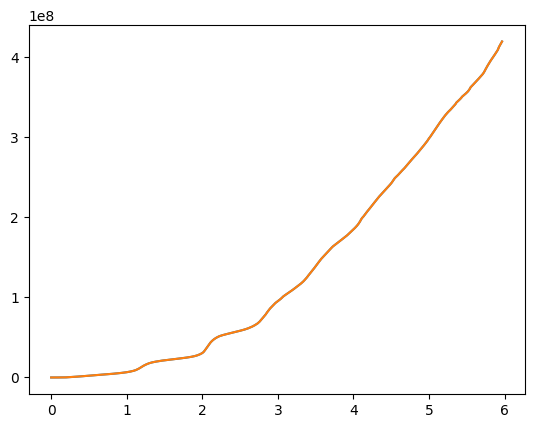

In [308]:

subdat = ts_data[halo_id]['data']
normq = subdat[ParamKeys.satellite_tidal_heating_normalized]
t_since_infall = cosmo.age(zsnaps) - t_infall

normq_spline = CubicSpline(np.flip(t_since_infall), np.flip(normq))

normq_spline.derivative()
plt.plot(t_since_infall, normq)
plt.plot(t_since_infall, normq_spline(t_since_infall))

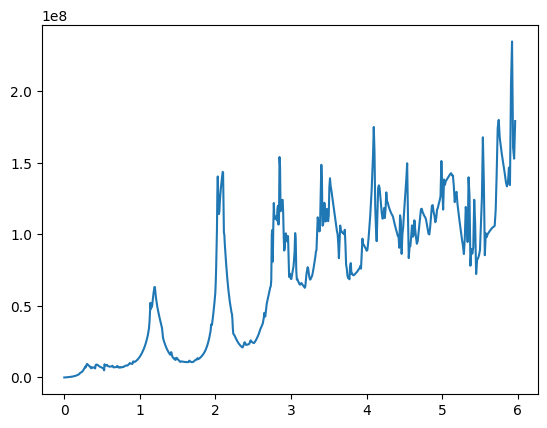

In [309]:
plt.plot(t_since_infall, normq_spline.derivative()(t_since_infall))

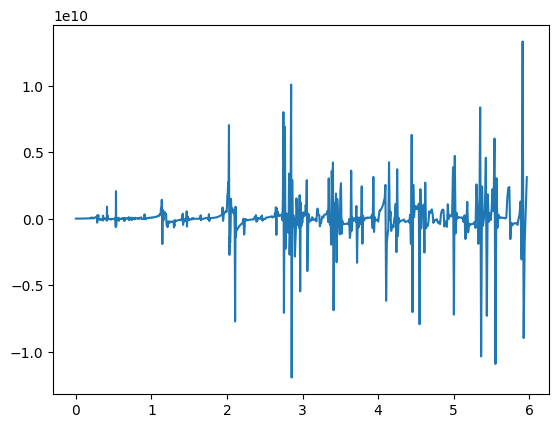

In [310]:
plt.plot(t_since_infall, normq_spline.derivative().derivative()(t_since_infall))

In [322]:
def get_acceleration_neartides(r, tidalf, alpha=0.5):
    return tidalf * alpha * r

def get_velocity_kick_neartides(r, tidalf, alpha=0.5):
    return np.sqrt(tidalf * alpha) * r



def get_velocity_kick_energy(r, normq_spline, rs, rv, mass):
    rs = rs * 1e3 * apu.kpc
    rv = rv * 1e3 * apu.kpc
    r = r * 1e3 * apu.kpc
    _G = G.to(apu.kpc**3 / (apu.M_sun * apu.Myr**2))

    nfw_profile =  profile_nfw.NFWProfile(M=mass, c=rv/rs, z=1.6, mdef='vir')

    menc = nfw_profile.enclosedMass(r.value) * apu.M_sun
    
    dq = (normq_spline.derivative()(1.7798) /  apu.Gyr**3).to(apu.Myr**(-3)) 

    vc = (nfw_profile.circularVelocity(r.value) * apu.km / apu.s).to(apu.kpc / apu.Myr)

    return 2 * r**4 / (_G * menc) * (dq)
    

In [324]:

snapi = -550
rv = subdat[ParamKeys.rvir][snapi]
rs = subdat[ParamKeys.scale_radius][snapi]
ft = subdat[ParamKeys.satellite_tidal_field][snapi]
mass = subdat[ParamKeys.mass_bound][snapi]
mass_inf = subdat[ParamKeys.mass_basic][snapi]
print(t_since_infall[snapi])
r = np.linspace(0.01 * rv,rv, 100)
a = get_velocity_kick_energy(r, normq_spline, rs, rv, mass)
print(a.unit)
print(a.to(apu.Mpc / apu.Gyr))

1.7798044447598933
kpc / Myr
[2.14533095e-01 1.02040514e+00 2.68111824e+00 5.48573263e+00
 9.74759917e+00 1.58033333e+01 2.40119626e+01 3.47542043e+01
 4.84318425e+01 6.54671845e+01 8.63025799e+01 1.11399991e+02
 1.41240610e+02 1.76324504e+02 2.17170301e+02 2.64314894e+02
 3.18313175e+02 3.79737781e+02 4.49178866e+02 5.27243881e+02
 6.14557373e+02 7.11760797e+02 8.19512332e+02 9.38486717e+02
 1.06937509e+03 1.21288482e+03 1.36973941e+03 1.54067830e+03
 1.72645677e+03 1.92784582e+03 2.14563203e+03 2.38061747e+03
 2.63361955e+03 2.90547098e+03 3.19701960e+03 3.50912832e+03
 3.84267503e+03 4.19855250e+03 4.57766827e+03 4.98094461e+03
 5.40931842e+03 5.86374112e+03 6.34517863e+03 6.85461125e+03
 7.39303361e+03 7.96145461e+03 8.56089733e+03 9.19239895e+03
 9.85701073e+03 1.05557979e+04 1.12898398e+04 1.20602293e+04
 1.28680733e+04 1.37144926e+04 1.46006215e+04 1.55276080e+04
 1.64966137e+04 1.75088137e+04 1.85653969e+04 1.96675652e+04
 2.08165343e+04 2.20135330e+04 2.32598036e+04 2.45566015

[]

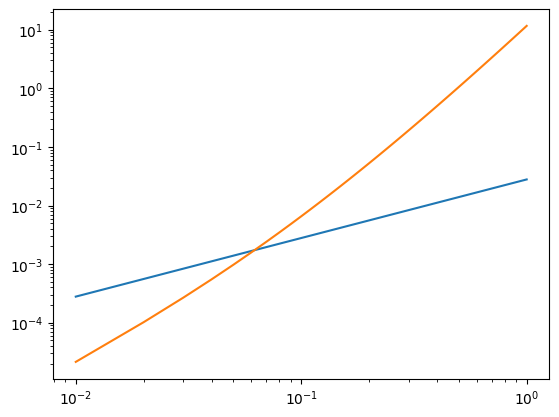

In [326]:
plt.plot(r / rv, get_velocity_kick_neartides(r, tidalf=ft, alpha=0.5))
plt.plot(r / rv, get_velocity_kick_energy(r, normq_spline, rs, rv, mass).to(apu.Mpc / apu.Gyr) / 1e4)
plt.loglog()